In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from collections import defaultdict
import copy
import os
import pprint
import itertools

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='white', font_scale=7, palette=sns.color_palette('Set2'),)
import matplotlib.pyplot as plt
import matplotlib
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm
import duckdb

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
alt_ids = {
    # NavierStokesDim64
    # ('c2f2fz7j', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    ('eijvq9xb', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    
    # NavierStokesDim256
    # ('y68jj7ko', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=97616566
    # ('bmqxrqdh', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=97616566
    
    # EnSF NaN
    # ('z19i455i', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=715319214
    # ('5561y8s3', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=715319214
    
    # ('uoc15dkh', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
    # ('jerb4qqb', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=2376999025

    # ('3hf2n7qc', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('ysi1pcmv', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('jygkacfh', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=715319214
    # ('yc5q95az', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=715319214

    # ('in7i7zwn', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=2376999025
}

In [4]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

In [5]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [13]:
variable_name = 'Ensemble size'
def variable(cfg):
    return pl.lit(cfg.dataset.predicted_state_count).alias(variable_name)
alt_ids = pl.DataFrame(
    orient='row',
    schema=[
        'alt_id', 'label',
    ],
    data=[
        ['3wnjb5aj', 'EnSF'],
        ['22ezufje', 'EnFF-OT'],
        ['xyu9cfx2', 'EnFF-F2P'],
    ],
)
alt_ids = duckdb.sql("""
select
    alt_ids.*,
    rng_seed
from alt_ids
join Conf on Conf.alt_id = alt_ids.alt_id
""").pl()
alt_ids

alt_id,label,rng_seed
str,str,i64
"""3wnjb5aj""","""EnSF""",97616566
"""22ezufje""","""EnFF-OT""",97616566
"""xyu9cfx2""","""EnFF-F2P""",97616566


In [14]:
cfgs = session.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_(alt_ids.get_column('alt_id'))))
cfgs = {c.alt_id: c for (c,) in cfgs}
cfgs = {k: {'cfg': cfgs[k]} for k in cfgs}

In [15]:
time_step = -1

In [17]:
for k, v in tqdm(cfgs.items()):
    cfg = v['cfg']
    path = cfg.run_dir/f'{cfg.prediction_filename}.parquet'
    if not path.exists():
        path = f'/mnta/taosData/dafm/runs_sci_2025-05/{cfg.alt_id}/{cfg.prediction_filename}.parquet'
    trajectory = (
        pl.scan_parquet(
            # cfg.run_dir/f'{cfg.prediction_filename}.parquet',
            # f'/mnta/taosData/dafm/runs_sci_2025-05/{k[0]}/{cfg.prediction_filename}.parquet',
            path,
        )
        .select(
            pl.selectors.starts_with('predicted_state_mean_')
        )
        .gather_every(cfg.dataset.observe_every_n_time_steps, 1)
        .collect()
    )
    trajectory = trajectory.to_numpy()
    trajectory = rearrange(
        trajectory,
        'time_step_count (value_count grid_horizontal_count grid_vertical_count) -> time_step_count value_count grid_horizontal_count grid_vertical_count',
        value_count=3, grid_vertical_count=cfg.dataset.grid_vertical_count, grid_horizontal_count=cfg.dataset.grid_horizontal_count,
    )[time_step]
    v['trajectory'] = trajectory

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:33<00:00, 11.18s/it]


In [18]:
rng = np.random.default_rng(utils.RNG_RANDBITS[cfg.rng_seed])
dynamics = datasets.get_dynamics_dataset(cfg.dataset, rng, device='cpu')

In [19]:
data_list = []
for t, (true_state, ignore_observation) in tqdm(enumerate(
    itertools.chain([(dynamics.true_state, True)], ((dynamics.true_state, ignore_observation) for *_, ignore_observation in dynamics))
), total=cfg.dataset.time_step_count - cfg.dataset.time_step_count_drop_first + 1):
    if not ignore_observation:
        data_list.append(true_state)
true_state = rearrange(
    data_list,
    'time_step_count 1 (value_count grid_horizontal_count grid_vertical_count) -> time_step_count value_count grid_horizontal_count grid_vertical_count',
    value_count=3, grid_vertical_count=cfg.dataset.grid_vertical_count, grid_horizontal_count=cfg.dataset.grid_horizontal_count,
)[time_step].numpy()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6001/6001 [03:22<00:00, 29.66it/s]


In [20]:
true_state.shape

(3, 256, 256)

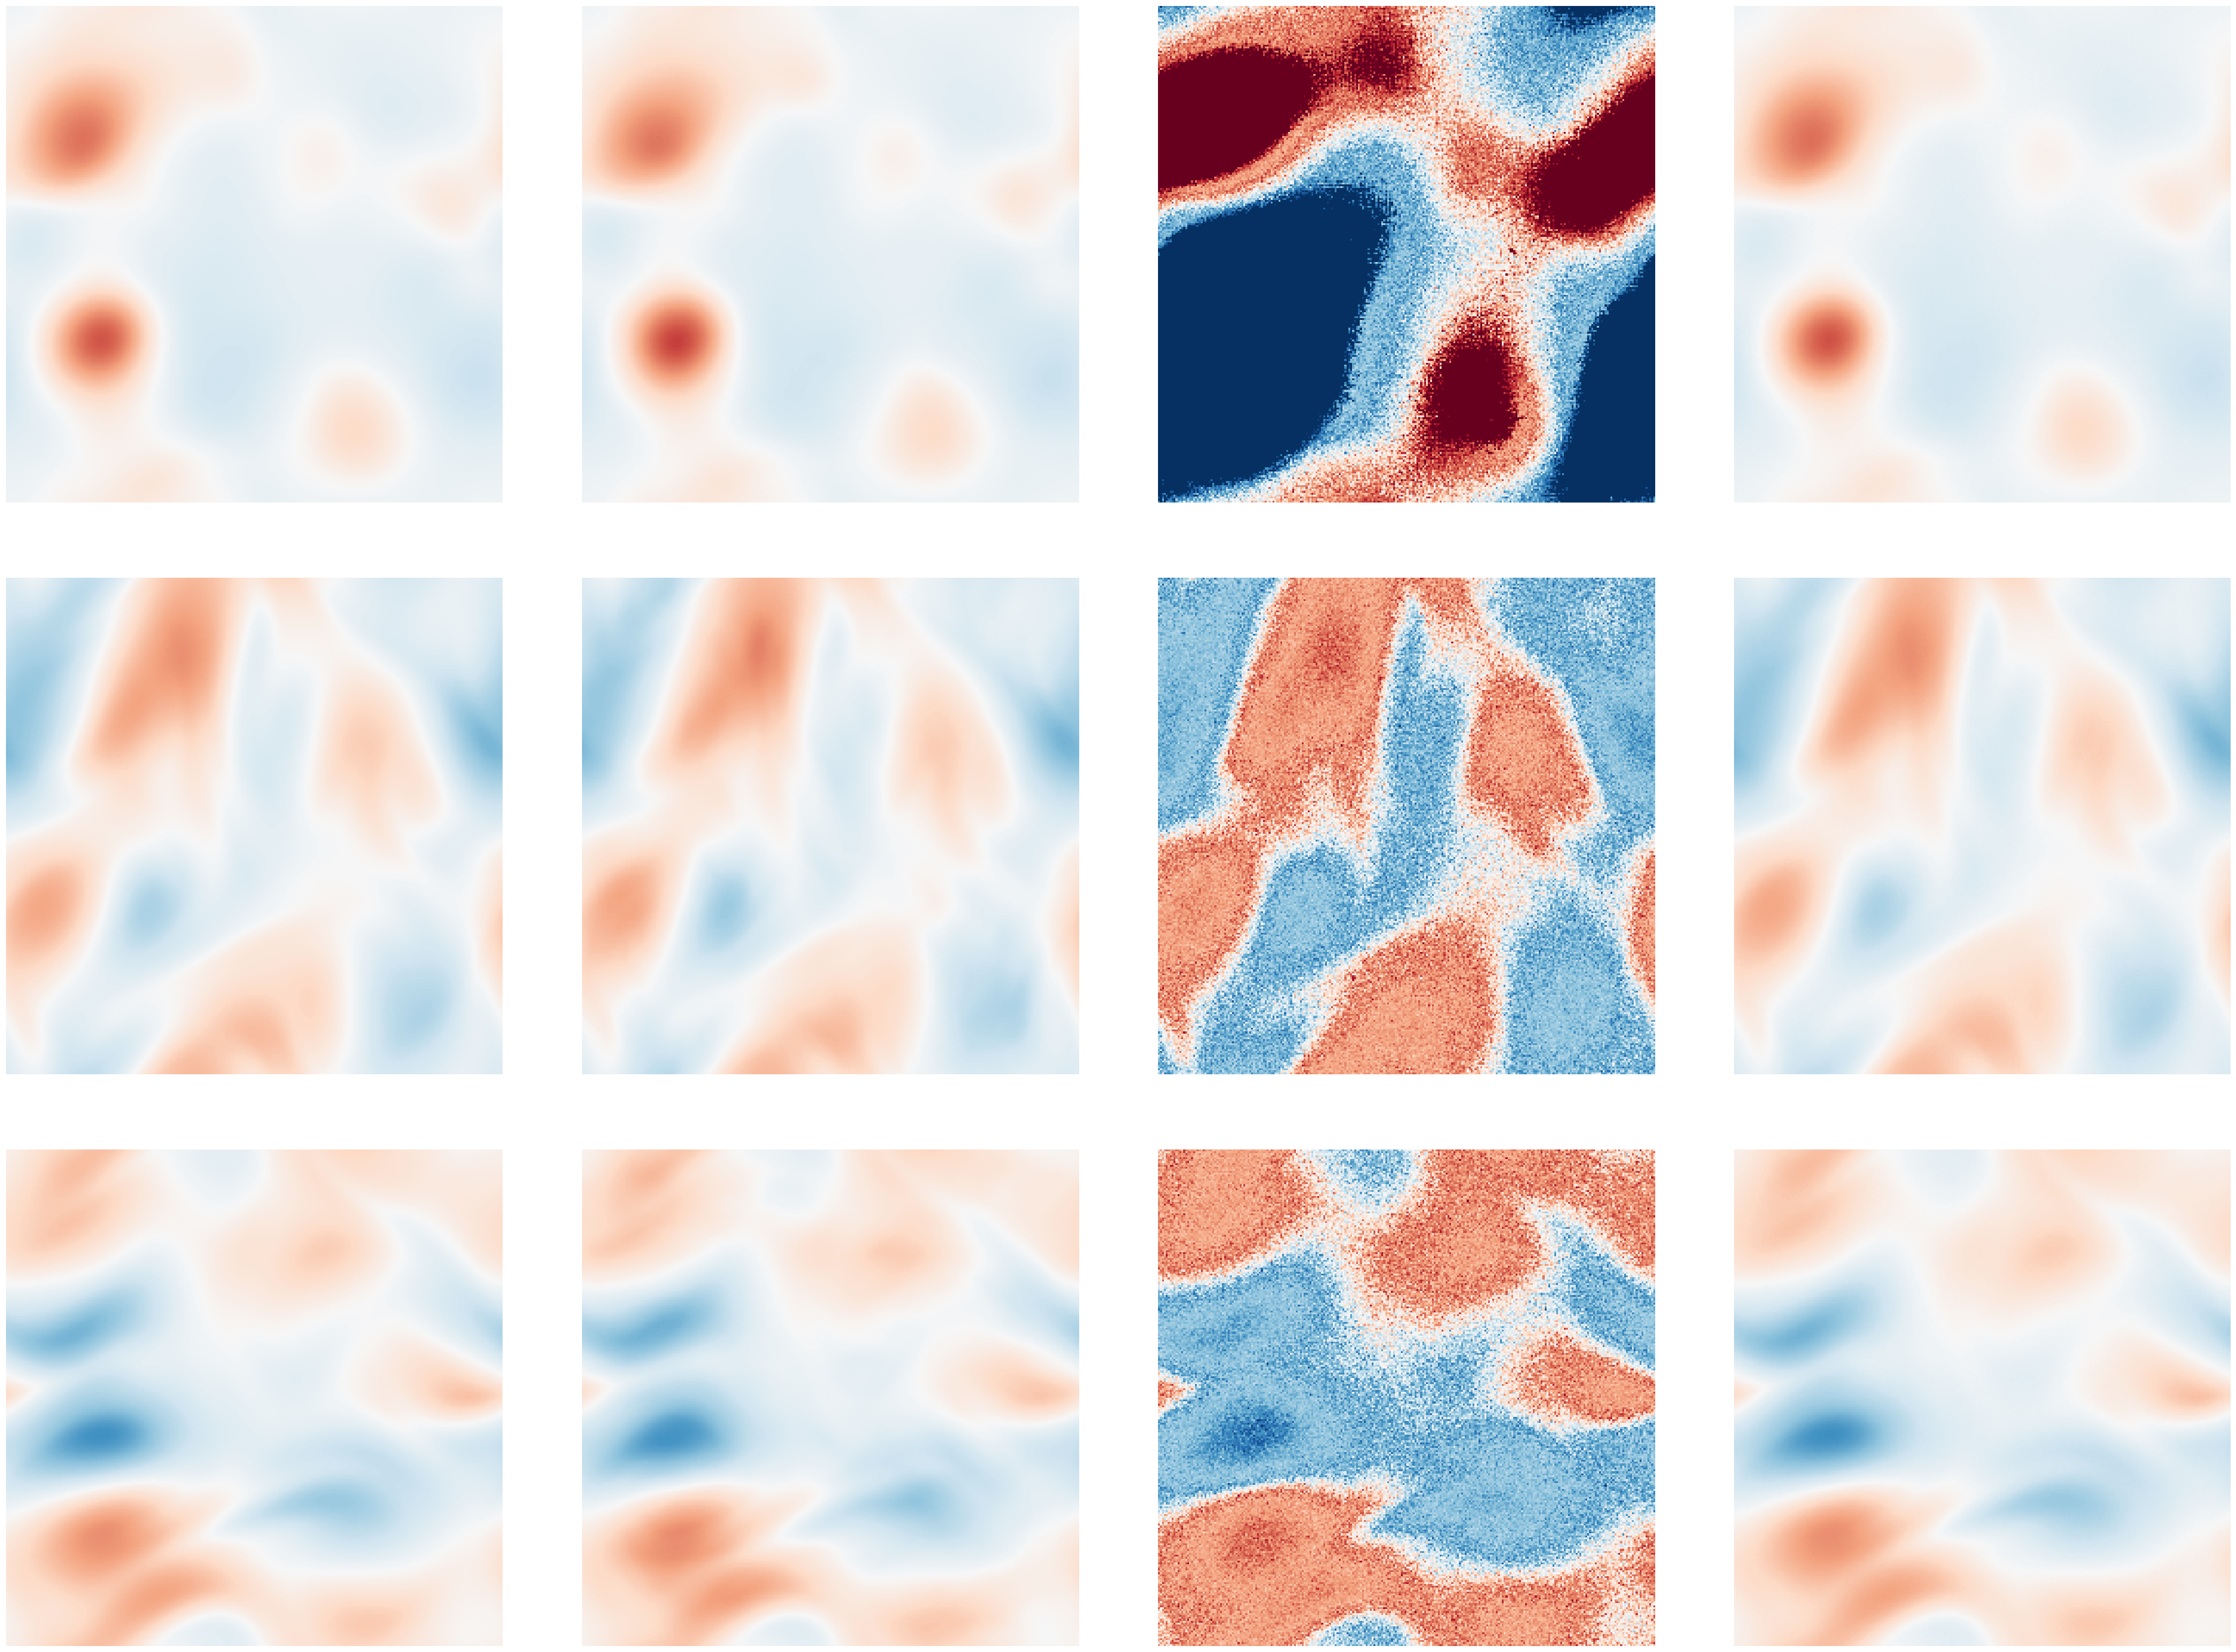

In [30]:
show_error = False
g = (
    sns.FacetGrid(
        data=pd.DataFrame({k: list(map(str, range(true_state.shape[0]))) for k in ['True', *cfgs]}).melt(var_name='Model', value_name='Value'),
        height=10,
        row='Value',
        col='Model',
    )
    .set_titles('')
)
v_min, v_max = None, None
for data in [true_state, *[v['trajectory'] for v in cfgs.values()]]:
    if show_error:
        data = data - true_state
    p = 0.05
    _v_min = np.quantile(data, p)
    _v_max = np.quantile(data, 1 - p)
    if v_min is None or v_min > _v_min:
        v_min = _v_min
    if v_max is None or v_max > _v_max:
        v_max = _v_max
v_absmax = max(map(abs, (v_min, v_max)))
for (row, col, hue), _ in g.facet_data():
    ax = g.axes[row, col]
    ax.set_axis_off()
    model_name = g.col_names[col]
    if model_name == 'True':
        data = true_state[row]
    else:
        data = cfgs[model_name]['trajectory'][row]
    if show_error:
        data = data - true_state[row]
    im_out = ax.imshow(data, cmap='RdBu', vmin=-v_absmax, vmax=v_absmax)
g.tight_layout()
# g.figure.subplots_adjust(right=.8)
# cbar_ax = g.figure.add_axes([0.85, 0.17, 0.02, 0.7])
# g.figure.colorbar(im_out, cax=cbar_ax)

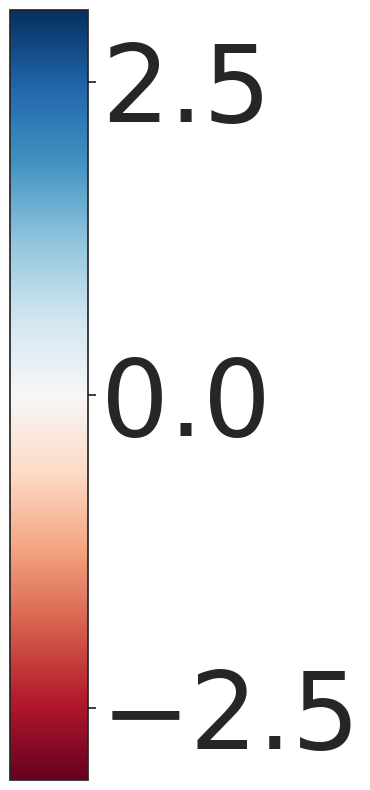

In [28]:
fig, ax = plt.subplots(figsize=(1, 10))
fig.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=-v_absmax, vmax=v_absmax), cmap='RdBu'), cax=ax)
title = 'Error' if show_error else 'Trajectory'
fig.savefig(f'{title}.colorbar.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)

In [29]:
plots.save_all_subfigures(g, title, renaming=dict(alt_ids[['alt_id', 'label']].iter_rows()))